# Stage 10b — Time Series and Classification

## 1. Goal

Use only past returns to predict whether the next return is positive.

In [1]:
from pathlib import Path
import os

import ipynbname

try:
    HOMEWORK_DIR = Path(ipynbname.path()).resolve().parent
except (FileNotFoundError, IndexError):
    HOMEWORK_DIR = Path.cwd().resolve()
    candidate = HOMEWORK_DIR / "homework" / "homework10b"
    if candidate.is_dir():
        HOMEWORK_DIR = candidate
os.chdir(HOMEWORK_DIR)
print("Working from:", HOMEWORK_DIR.name)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

Working from: homework10b


## 2. Data, features, and target

Every feature is shifted so it is known before the target period. The target is the sign of the next return.

In [2]:
dates = pd.bdate_range("2023-01-02", periods=650)
returns = np.zeros(len(dates))
innovations = rng.normal(0.0004, 0.011, len(dates))
for index in range(1, len(dates)):
    returns[index] = 0.18 * returns[index - 1] + innovations[index]

data = pd.DataFrame({"return_1d": returns}, index=dates)
data["price"] = 100 * (1 + data["return_1d"]).cumprod()
past_returns = data["return_1d"].shift(1)
data["lag_1"] = past_returns
data["rolling_mean_5"] = past_returns.rolling(5).mean()
data["rolling_std_10"] = past_returns.rolling(10).std()
data["momentum_5"] = data["price"].shift(1).pct_change(5)
data["next_return"] = data["return_1d"].shift(-1)
data = data.dropna().copy()
data["y_up"] = (data["next_return"] > 0).astype(int)
data.head()

,return_1d,price,lag_1,rolling_mean_5,rolling_std_10,momentum_5,next_return,y_up
2023-01-16,0.008444,96.574790,-0.009052,-0.006278,0.009884,-0.031095,0.010476,1
2023-01-17,0.010476,97.586471,0.008444,-0.001123,0.010622,-0.005684,0.003012,1
2023-01-18,0.003012,97.880397,0.010476,0.001234,0.011079,0.006052,0.013342,1
2023-01-19,0.013342,99.186298,0.003012,0.002500,0.010845,0.012439,0.007944,1
2023-01-20,0.007944,99.974247,0.013342,0.005244,0.011046,0.026338,-0.007622,0


## 3. Time-aware split and pipeline

The oldest 75% trains the model and the newest 25% evaluates it. No random shuffle is used.

In [3]:
features = ["lag_1", "rolling_mean_5", "rolling_std_10", "momentum_5"]
split = int(len(data) * 0.75)
train, test = data.iloc[:split], data.iloc[split:]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=RANDOM_SEED)),
])
pipeline.fit(train[features], train["y_up"])
predicted = pipeline.predict(test[features])

metrics = pd.Series({
    "accuracy": accuracy_score(test["y_up"], predicted),
    "precision": precision_score(test["y_up"], predicted, zero_division=0),
    "recall": recall_score(test["y_up"], predicted, zero_division=0),
    "f1": f1_score(test["y_up"], predicted, zero_division=0),
})
print("Train end:", train.index.max().date())
print("Test start:", test.index.min().date())
metrics

Train end: 2024-11-14
Test start: 2024-11-15


accuracy     0.543750
precision    0.531915
recall       0.632911
f1           0.578035
dtype: float64

## 4. Evaluation

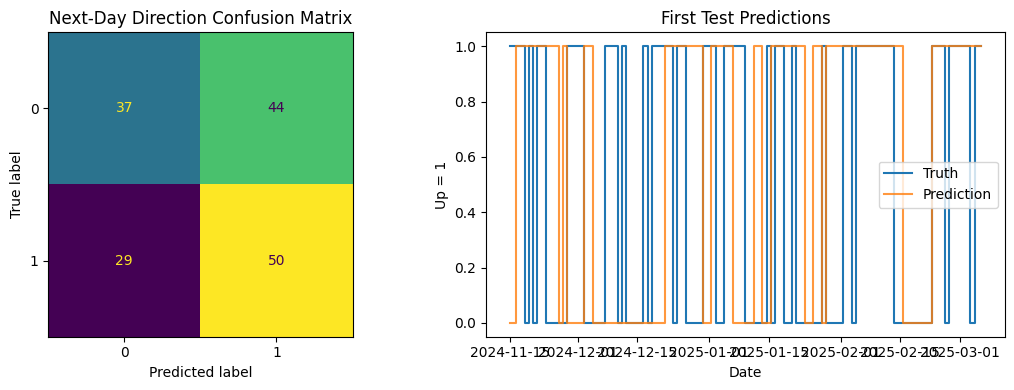

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(test["y_up"], predicted, ax=axes[0], colorbar=False)
axes[0].set_title("Next-Day Direction Confusion Matrix")

display_rows = min(80, len(test))
axes[1].step(test.index[:display_rows], test["y_up"].iloc[:display_rows], where="mid", label="Truth")
axes[1].step(test.index[:display_rows], predicted[:display_rows], where="mid", label="Prediction", alpha=0.8)
axes[1].set(title="First Test Predictions", xlabel="Date", ylabel="Up = 1")
axes[1].legend()
fig.tight_layout()
plt.show()

## 5. Interpretation

The pipeline is leakage-aware and reproducible, but performance is only a baseline. A short simulated autocorrelation gives the model some structure, while changing volatility and weak signals still create many errors. I would not treat accuracy alone as trading profitability; transaction costs, class balance, calibration, and walk-forward stability also matter.